# Healthcare Data Cleaning & Analysis

## Objective
This project cleans healthcare data and performs exploratory data analysis to identify patterns in length of stay, billing, and medical conditions.


In [18]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("healthcare_dataset.csv")
df.head()


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


## Initial Data Review

In [19]:
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [20]:
df.columns

Index(['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition',
       'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider',
       'Billing Amount', 'Room Number', 'Admission Type', 'Discharge Date',
       'Medication', 'Test Results'],
      dtype='object')

In [21]:
df.isna().sum()

,0
Name,0
Age,0
Gender,0
Blood Type,0
Medical Condition,0
Date of Admission,0
Doctor,0
Hospital,0
Insurance Provider,0
Billing Amount,0


## Data Cleaning

In [22]:
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_")
)
df.columns


Index(['name', 'age', 'gender', 'blood_type', 'medical_condition',
       'date_of_admission', 'doctor', 'hospital', 'insurance_provider',
       'billing_amount', 'room_number', 'admission_type', 'discharge_date',
       'medication', 'test_results'],
      dtype='object')

In [23]:
df["date_of_admission"] = pd.to_datetime(df["date_of_admission"], errors="coerce")
df["discharge_date"] = pd.to_datetime(df["discharge_date"], errors="coerce")


In [24]:
df[["date_of_admission", "discharge_date"]].head()

,date_of_admission,discharge_date
0,2024-01-31,2024-02-02
1,2019-08-20,2019-08-26
2,2022-09-22,2022-10-07
3,2020-11-18,2020-12-18
4,2022-09-19,2022-10-09


In [25]:
df["length_of_stay"] = (df["discharge_date"] - df["date_of_admission"]).dt.days
df[["date_of_admission", "discharge_date", "length_of_stay"]].head()


,date_of_admission,discharge_date,length_of_stay
0,2024-01-31,2024-02-02,2
1,2019-08-20,2019-08-26,6
2,2022-09-22,2022-10-07,15
3,2020-11-18,2020-12-18,30
4,2022-09-19,2022-10-09,20


In [26]:
before = len(df)
df = df.drop_duplicates()
after = len(df)

print("Rows before:", before)
print("Rows after :", after)
print("Duplicates removed:", before - after)


Rows before: 55500
Rows after : 54966
Duplicates removed: 534


In [27]:
text_cols = ["name", "gender", "blood_type", "medical_condition", "doctor", "hospital",
             "insurance_provider", "admission_type", "medication", "test_results"]

for col in text_cols:
    df[col] = df[col].astype(str).str.strip()


In [28]:
df["billing_amount"] = pd.to_numeric(df["billing_amount"], errors="coerce")
df["billing_amount"].describe()


,billing_amount
count,54966.000000
mean,25544.306284
std,14208.409711
min,-2008.492140
25%,13243.718641
50%,25542.749145
75%,37819.858159
max,52764.276736


In [29]:
median_bill = df["billing_amount"].median()
df["billing_amount"] = df["billing_amount"].fillna(median_bill)

median_bill


25542.749144555833

In [30]:
df = df.dropna(subset=["date_of_admission", "discharge_date"])

In [31]:
df.isna().sum()

,0
name,0
age,0
gender,0
blood_type,0
medical_condition,0
date_of_admission,0
doctor,0
hospital,0
insurance_provider,0
billing_amount,0


In [32]:
df.describe(include="all")

,name,age,gender,blood_type,medical_condition,date_of_admission,doctor,hospital,insurance_provider,billing_amount,room_number,admission_type,discharge_date,medication,test_results,length_of_stay
count,54966,54966.000000,54966,54966,54966,54966,54966,54966,54966,54966.000000,54966.000000,54966,54966,54966,54966,54966.000000
unique,49992,NaN,2,8,6,NaN,40341,39876,5,NaN,NaN,3,NaN,5,3,NaN
top,DAvId muNoZ,NaN,Male,A-,Arthritis,NaN,Michael Smith,LLC Smith,Cigna,NaN,NaN,Elective,NaN,Lipitor,Abnormal,NaN
freq,3,NaN,27496,6898,9218,NaN,27,44,11139,NaN,NaN,18473,NaN,11038,18437,NaN
mean,NaN,51.535185,NaN,NaN,NaN,2021-11-01 17:35:29.505512448,NaN,NaN,NaN,25544.306284,301.124404,NaN,2021-11-17 05:34:28.202161408,NaN,NaN,15.499290
min,NaN,13.000000,NaN,NaN,NaN,2019-05-08 00:00:00,NaN,NaN,NaN,-2008.492140,101.000000,NaN,2019-05-09 00:00:00,NaN,NaN,1.000000
25%,NaN,35.000000,NaN,NaN,NaN,2020-07-28 00:00:00,NaN,NaN,NaN,13243.718641,202.000000,NaN,2020-08-13 00:00:00,NaN,NaN,8.000000
50%,NaN,52.000000,NaN,NaN,NaN,2021-11-02 00:00:00,NaN,NaN,NaN,25542.749145,302.000000,NaN,2021-11-18 00:00:00,NaN,NaN,15.000000
75%,NaN,68.000000,NaN,NaN,NaN,2023-02-03 00:00:00,NaN,NaN,NaN,37819.858159,401.000000,NaN,2023-02-19 00:00:00,NaN,NaN,23.000000
max,NaN,89.000000,NaN,NaN,NaN,2024-05-07 00:00:00,NaN,NaN,NaN,52764.276736,500.000000,NaN,2024-06-06 00:00:00,NaN,NaN,30.000000


In [33]:
df["name"] = df["name"].astype(str).str.strip().str.title()
df["name"].head()


,name
0,Bobby Jackson
1,Leslie Terry
2,Danny Smith
3,Andrew Watts
4,Adrienne Bell


In [34]:
clean_file = "healthcare_dataset_clean.csv"
df.to_csv(clean_file, index=False)
clean_file


'healthcare_dataset_clean.csv'

## Visualizations

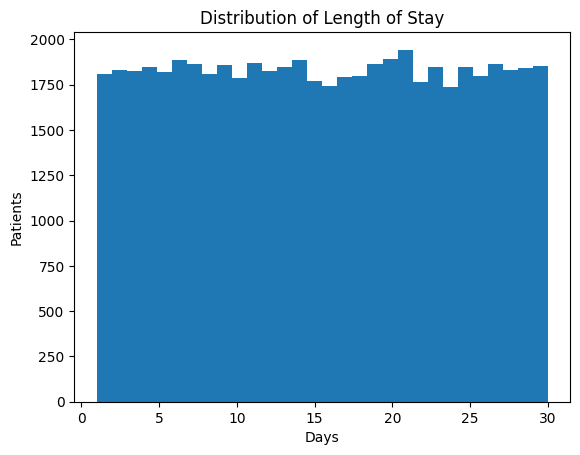

In [35]:
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_")
)

df["date_of_admission"] = pd.to_datetime(df["date_of_admission"], errors="coerce")
df["discharge_date"] = pd.to_datetime(df["discharge_date"], errors="coerce")
df["length_of_stay"] = (df["discharge_date"] - df["date_of_admission"]).dt.days

plt.hist(df["length_of_stay"], bins=30)
plt.title("Distribution of Length of Stay")
plt.xlabel("Days")
plt.ylabel("Patients")
plt.show()

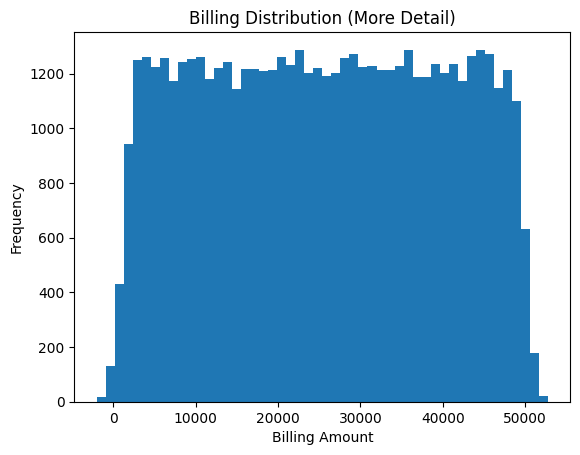

In [40]:
plt.hist(df['billing_amount'], bins=50)
plt.title('Billing Distribution (More Detail)')
plt.xlabel('Billing Amount')
plt.ylabel('Frequency')
plt.show()

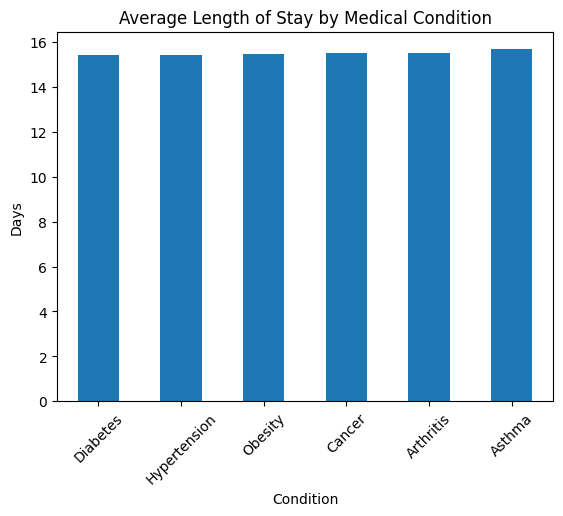

In [38]:
df.groupby("medical_condition")["length_of_stay"].mean().sort_values().plot(kind="bar")
plt.title("Average Length of Stay by Medical Condition")
plt.xlabel("Condition")
plt.ylabel("Days")
plt.xticks(rotation=45)
plt.show()


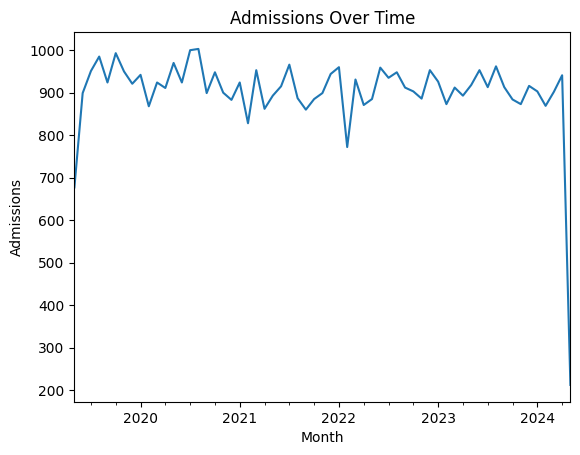

In [39]:
df.groupby(df["date_of_admission"].dt.to_period("M")).size().plot()
plt.title("Admissions Over Time")
plt.xlabel("Month")
plt.ylabel("Admissions")
plt.show()


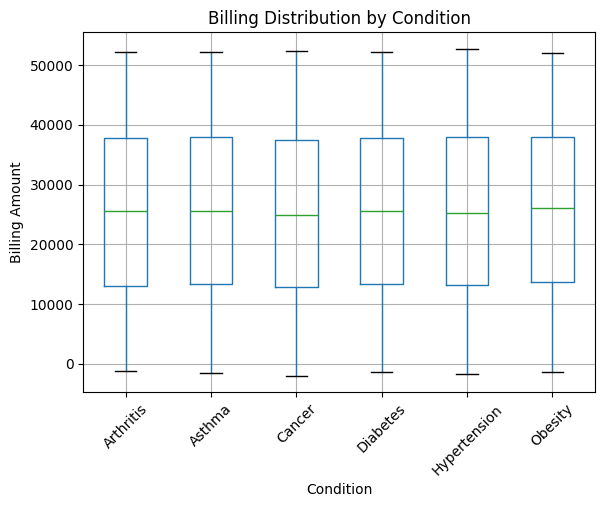

In [41]:
df.boxplot(column='billing_amount', by='medical_condition', rot=45)
plt.title('Billing Distribution by Condition')
plt.suptitle('')
plt.xlabel('Condition')
plt.ylabel('Billing Amount')
plt.show()

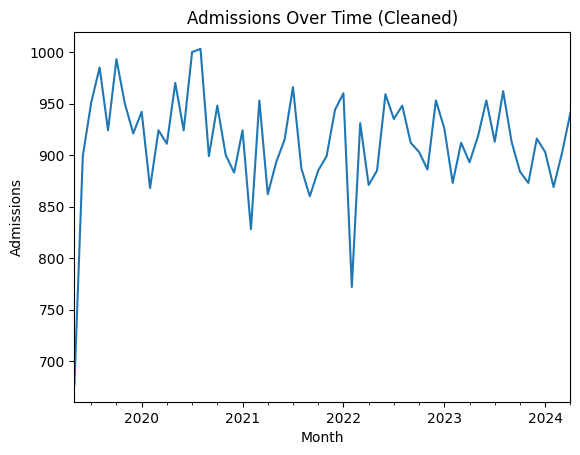

In [44]:
df_time = df.copy()
df_time['month'] = df_time['date_of_admission'].dt.to_period('M')

monthly = df_time.groupby('month').size()

monthly = monthly[:-1]  # remove incomplete last month

monthly.plot()
plt.title('Admissions Over Time (Cleaned)')
plt.xlabel('Month')
plt.ylabel('Admissions')
plt.show()

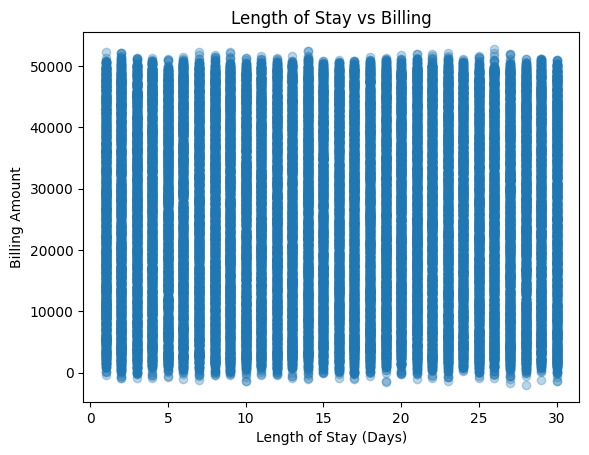

In [46]:
plt.scatter(df['length_of_stay'], df['billing_amount'], alpha=0.3)
plt.title('Length of Stay vs Billing')
plt.xlabel('Length of Stay (Days)')
plt.ylabel('Billing Amount')
plt.show()

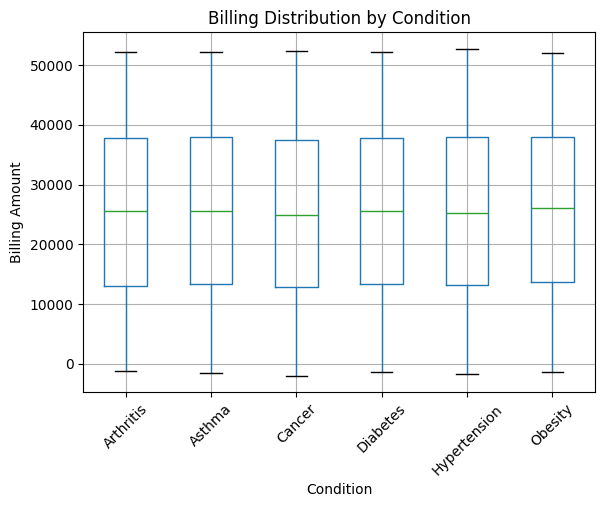

In [47]:
df.boxplot(column='billing_amount', by='medical_condition', rot=45)
plt.title('Billing Distribution by Condition')
plt.suptitle('')
plt.xlabel('Condition')
plt.ylabel('Billing Amount')
plt.show()

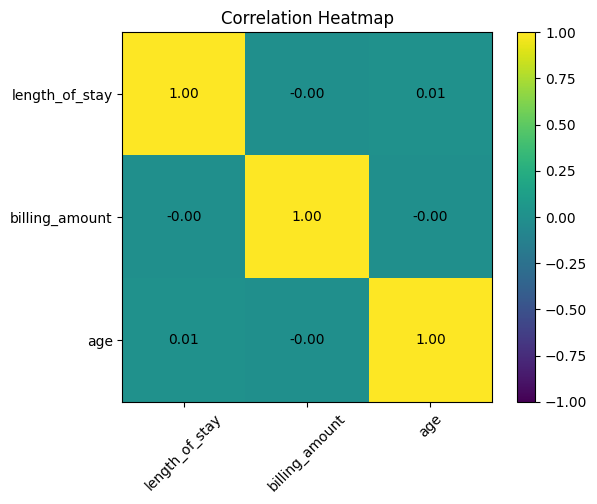

In [56]:
corr = df[['length_of_stay', 'billing_amount', 'age']].corr()

fig, ax = plt.subplots()
im = ax.imshow(corr, vmin=-1, vmax=1)

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45)
ax.set_yticklabels(corr.columns)

for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha='center', va='center')

plt.colorbar(im)
plt.title('Correlation Heatmap')
plt.show()

The correlation analysis suggests weak linear relationships between age, billing amount, and length of stay. This indicates that cost and hospital stay may be influenced by other variables not captured in this small numeric subset.

## Outlier Analysis
Identifying high-cost patients that may drive healthcare spending.

In [53]:
high_cost = df[df['billing_amount'] > df['billing_amount'].quantile(0.95)]

high_cost[['medical_condition', 'billing_amount']].head()


,medical_condition,billing_amount
5,Asthma,48145.110951
8,Asthma,50119.222792
30,Asthma,47909.128810
38,Diabetes,48290.693407
40,Hypertension,49943.278499


In [51]:
len(high_cost), len(df)

(2749, 54966)

In [52]:
high_cost['medical_condition'].value_counts()

,count
medical_condition,
Hypertension,475
Diabetes,467
Arthritis,465
Asthma,462
Obesity,460
Cancer,420


In [54]:
print("High cost avg:", high_cost['billing_amount'].mean())
print("Overall avg:", df['billing_amount'].mean())

High cost avg: 49032.74470346715
Overall avg: 25544.306284383965


In [55]:
high_cost.groupby('medical_condition')['billing_amount'].mean().sort_values(ascending=False)

,billing_amount
medical_condition,
Arthritis,49117.712004
Cancer,49103.575851
Hypertension,49025.675038
Asthma,49002.853068
Diabetes,49001.437500
Obesity,48951.287343


### Insight

The top 5% of patients represent high-cost cases and contribute disproportionately to overall healthcare spending. Conditions such as asthma, diabetes, and hypertension appear frequently among these high-cost patients. Additionally, the average billing amount for this group is significantly higher than the overall dataset, indicating a concentration of costs among a small subset of patients.

## Business Question

Which medical conditions are the most expensive, and how does length of stay impact total cost?

## Key Insights

- The dataset shows relatively uniform distributions, suggesting synthetic or evenly distributed data
- There is limited variation in average billing across medical conditions
- High-cost patients (top 5%) contribute disproportionately to total healthcare spending
- Weak correlation between length of stay and billing suggests other factors influence cost
- Admissions remain relatively stable over time with minor fluctuations